In [28]:
import cv2
import io
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dctn, idctn
from skimage.metrics import structural_similarity as ssim

In [29]:
BASE_QUANTIZATION_MATRIX = np.array([
  [16,11,10,16,24,40,51,61],
  [12,12,14,19,26,58,60,55],
  [14,13,16,24,40,57,69,56],
  [14,17,22,29,51,87,80,62],
  [18,22,37,56,68,109,103,77],
  [24,35,55,64,81,104,113,92],
  [49,64,78,87,103,121,120,101],
  [72,92,95,98,112,100,103,99]
], dtype=np.float32)

def get_quantization_matrix(quality=50):
  quality = np.clip(quality, 1, 100)
  scale = (5000 / quality) if quality < 50 else (200 - 2 * quality)
  return np.clip((BASE_QUANTIZATION_MATRIX * scale + 50) / 100, 1, 255)

Apply DCT in the function below. Convert the image into a numpy grayscale array then shift all the pixel values by 128. DCT works better when values are centered around zero.
Perform reshaping after that.

In [30]:
def process_image_dct(image, quantization_matrix):
  h, w = image.shape
  img_float = np.float32(image) - 128

  blocks = img_float.reshape(h // 8, 8, w // 8, 8).transpose(0, 2, 1, 3)

  dct_blocks = dctn(blocks, axes=(-2, -1), norm='ortho')
  quantized = np.round(dct_blocks / quantization_matrix)
  dequantized = quantized * quantization_matrix
  reconstruct = idctn(dequantized, axes=(-2, -1), norm='ortho')

  result = reconstruct.transpose(0, 2, 1, 3).reshape(h, w) + 128

  return np.clip(result, 0, 255).astype(np.uint8)

The goal of this function is to prove one of the core ideas behind JPEG: _Most image energy is concentrated in low frequencies._ 

In [31]:
def visualize_dct_coefficients(image):
  img_float = np.float32(image) - 128
  blocks = img_float.reshape(image.shape[0] // 8, 8, image.shape[1] // 8, 8).transpose(0, 2, 1, 3)
  dct_blocks = dctn(blocks, axes=(-2, -1), norm='ortho')

  avg_coeff = np.mean(np.abs(dct_blocks), axis=(0,1))

  plt.figure(figsize=(5, 4))
  plt.imshow(np.log(avg_coeff + 1), cmap='hot')
  plt.colorbar(label='log(|DCT coeff| + 1)')
  plt.title("Average DCT Coefficient Magnitude\n(log scale — energy concentrates top-left)")
  plt.xlabel("Horizontal frequency")
  plt.ylabel("Vertical frequency")
  plt.tight_layout()
  plt.savefig("dct_coefficients.png", dpi=150)
  plt.show()

In [ ]:
def compute_metrics(original, compressed):
  mse = np.mean((original.astype(np.float32) - compressed.astype(np.float32)) ** 2)

  psnr =  100.0 if mse == 0 else 20 * np.log10(255 / np.sqrt(mse))

  ssim_score = ssim(original, compressed)
  return mse, psnr, ssim_score, psnr_percent

In [33]:
def compute_size(img_array, quality=95):
  pil_img = Image.fromarray(img_array)
  buf = io.BytesIO()
  pil_img.save(buf, format='JPEG', quality=quality)
  return buf.tell() / 1024

In [ ]:
image = cv2.imread("images/sample.png", cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Image not found.")
  exit()

h, w = image.shape
image = image[:h - h % 8, :w - w % 8]
print(f"Image size: {image.shape}")

original_size = os.path.getsize("images/sample.jpg") / 1024
original_encoded = compute_size(image)
print(f"Image dimensions: {image.shape}")
print(f"Original Size: {original_size: .2f} KB")
print(f"Original Encoded Size: {original_encoded: .2f} KB")

quality_levels = [5, 25, 50, 75, 95]
results = []

for q in quality_levels:
  qm = get_quantization_matrix(q)
  comp = process_image_dct(image, qm)
  mse, psnr, ssim_score = compute_metrics(image, comp)
  comp_kb = compute_size(comp, quality=q)
  ratio = original_size / comp_kb
  results.append((q, comp, mse, psnr, ssim_score, comp_kb, ratio))

  print("\n")
  print(f"Compressed size in KB: {comp_kb:3.2f}")
  print(f"Quality Level: {q:3d}")
  print(f"MSE: {mse:8.2f}")
  print(f"PSNR: {psnr:6.2f} dB")
  print(f"SSIM: {ssim_score:4f}")


Image size: (2192, 2416)
Image dimensions: (2192, 2416)
Original Size:  2794.21 KB
Original Encoded Size:  648.13 KB


Compressed size in KB: 69.75
Quality Level:   5
MSE:    59.62
PSNR:  30.38 dB
SSIM: 0.838498


Compressed size in KB: 135.06
Quality Level:  25
MSE:     8.36
PSNR:  38.91 dB
SSIM: 0.953181


Compressed size in KB: 209.76
Quality Level:  50
MSE:     4.27
PSNR:  41.83 dB
SSIM: 0.975620


Compressed size in KB: 354.74
Quality Level:  75
MSE:     1.94
PSNR:  45.26 dB
SSIM: 0.990228


Compressed size in KB: 649.87
Quality Level:  95
MSE:     0.44
PSNR:  51.67 dB
SSIM: 0.997925


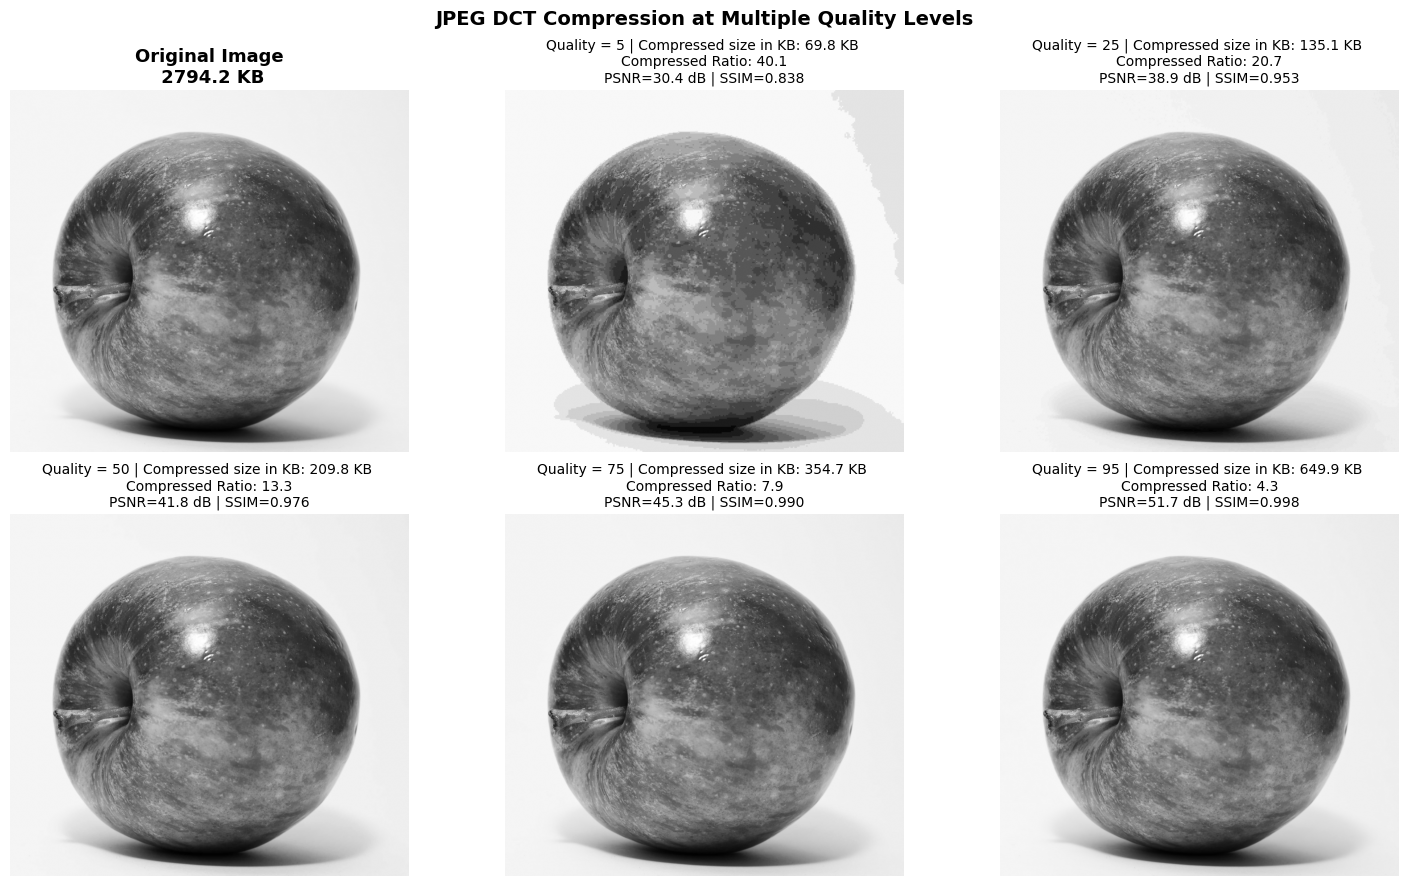

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

axes[0].imshow(image, cmap='gray')
axes[0].set_title(f"Original Image\n{original_size: .1f} KB", fontsize=13, fontweight='bold')
axes[0].axis("off")

for idx, (q, comp, mse, psnr, ssim_score, comp_kb, ratio) in enumerate(results, start=1):
  axes[idx].imshow(comp, cmap='gray')
  axes[idx].set_title(
    f"Quality = {q} | Compressed size in KB: {comp_kb:.1f} KB \nCompressed Ratio: {ratio:.1f}\nPSNR={psnr:.1f} dB | SSIM={ssim_score:.3f}",
    fontsize=10
  )
  axes[idx].axis("off")

plt.suptitle("JPEG DCT Compression at Multiple Quality Levels", fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig("compression_comparison.png", dpi=150)
plt.show()
# print(results)

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

labels = [f"Q={r[0]}" for r in results]
comp_sizes = [r[5] for r in results]
colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

bars = ax.bar(labels, comp_sizes, color=colors, edgecolor='black', linewidth=0.8, zorder=3)
ax.axhline(original_size, color='steelblue', linestyle='--', linewidth=2,
           label=f'Original ({original_size:.1f} KB)')

for bar, kb, ratio in zip(bars, comp_sizes, [r[6] for r in results]):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, 
          f"{kb:.1f} KB\n({ratio:.1f}x)", ha='center', va='bottom', fontsize=9, fontweight='bold'
          )
ax.set_xlabel("Quality Factor", fontsize=12)
ax.set_ylabel("File Size (KB)", fontsize=12)
ax.set_title("Compressed Image File Sizes vs Original", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_ylim(0, max(original_size, max(comp_sizes)) * 1.3)>
plt.tight_layout()
# plt.savefig("size_comparison_bar.png", dpi=150)
plt.show()

SyntaxError: invalid syntax (1879011273.py, line 20)

PSNR or Peak Signal to Noise Ratio measures how much noise was introduced by compression, expressed in decibels. 
<br>Formula is: `PSNR = 20log(255/sqrt(MSE))`<br>
here, MSE is the **Mean Squared Error**, which is the average squared difference between the original and compressed pixel values. <br>
PSNR lets us quantify exactly how much quality we are trading for file size at each quality level.

Next up, SSIM or Structural Similarity Index. Instead of comparing pixel values directly, SSIM compares three perceptual properties between patches of the image: `Luminance, Contrast, Structure`
<br>
An output in the range `[0, 1]` is achieved where 1 means nearly identical. Values over 0.95 are considered visually lossless.<br>
SSIM directly measures whether the structural information after performing DCT was preserved.
<br><br>
As the quality drops from 95 -> 5, the PSNR graph falls smoothly while the SSIM drops more sharply once blocking artifacts kick in.

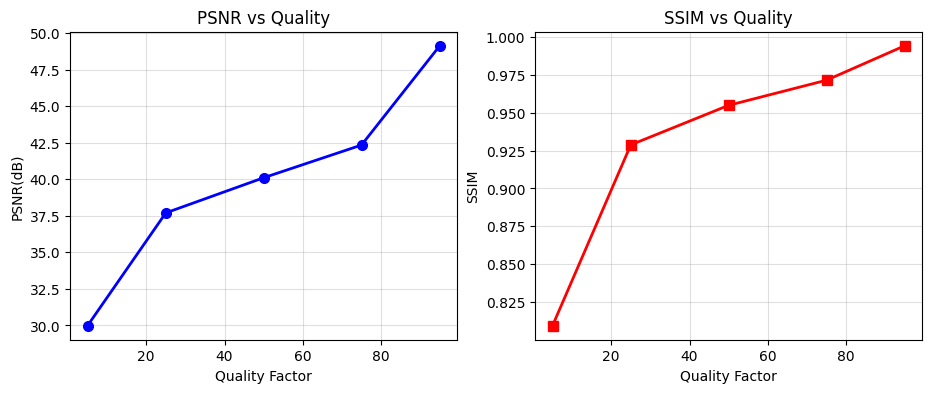

In [ ]:
qs = [r[0] for r in results]
psnrs = [r[3] for r in results]
ssims = [r[4] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(qs, psnrs, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel("Quality Factor")
ax1.set_ylabel("PSNR(dB)")
ax1.set_title("PSNR vs Quality")
ax1.grid(True, alpha=0.4)

ax2.plot(qs, ssims, 'rs-', linewidth=2, markersize=7)
ax2.set_xlabel("Quality Factor")
ax2.set_ylabel("SSIM")
ax2.set_title("SSIM vs Quality")
ax2.grid(True, alpha=0.4)

<Figure size 640x480 with 0 Axes>

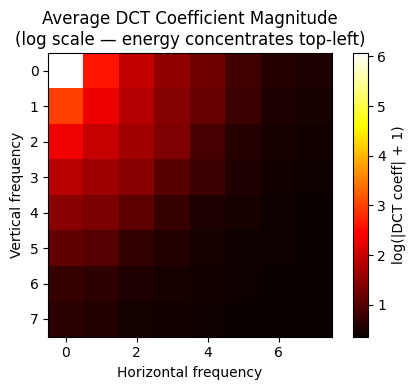

In [ ]:
plt.suptitle("Image Quality Metrics vs Compression Quality Factor", fontsize=13)
plt.tight_layout()
# plt.savefig("metrics_vs_quality.png", dpi=150)
plt.show()

visualize_dct_coefficients(image)